# Kinase KD × CytoSignal LR score elastic-net screen

## Purpose

This notebook is the first-stage screen for the kinase perturbation dataset with added CytoSignal LR scores. The goal is to identify a manageable set of LR scores that are informative for each kinase KD model before running expensive gene-level regressions.

The biological question is:

> For a kinase KD, which spatial ligand–receptor scores are most informative about the transcriptomic state of KD and control cells?

This notebook does not produce final gene-level p-values. It ranks LR scores for downstream testing.

## Input data

The input is the nine-slide kinase perturbation dataset, now stored as slide-level H5MU files:

```text
slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
...
slide9_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
```

Each H5MU contains:

- `rna`: the original kinase perturbation single-cell RNA object;
- `lr_cytosignal`: CytoSignal diffusion LR-score modality;
- LR score radii: 100, 200, and 400 µm.

The notebook concatenates the nine slides after prefixing cell IDs with the slide name, so repeated barcodes across slides cannot collide.

## Perturbation and control definition

This notebook follows the earlier kinase analysis logic from `Kinase_Ligand_Interaction_Distance_Analysis.ipynb`.

- Raw guide calls come from `rna.obs['guides_passing_str']`.
- Guides are mapped to gene-level kinase targets using `rna.uns['guide_protospacers']` and `rna.uns['gene_names_from_guides']` when possible.
- If the exported guide mapping is not pairwise or unavailable, guide names are parsed directly as a fallback.
- A cell is KD-positive for kinase `K` if its resolved target set contains `K`.
- Mixed or multi-target cells containing `K` are counted as KD-positive for `K`.
- Controls are explicit NTC / negative-control-only cells.
- Other kinase KD cells are not used as controls.

For each kinase target, cells used in the screen are:

```text
model cells = KD-positive cells for kinase K + explicit NTC control cells
```

## Model used for screening

The screen uses RNA principal components as a compact transcriptomic outcome. For a fixed kinase `K`, radius `r`, and a candidate LR score matrix, it fits a multi-task elastic net:

$$
\mathbf{Y}_{PC} \sim \mathbf{L}_{1}(r), \mathbf{L}_{2}(r), \ldots, \mathbf{L}_{m}(r)
$$

where:

- $\mathbf{Y}_{PC}$ is the cell × RNA-PC matrix;
- $\mathbf{L}_{j}(r)$ is CytoSignal LR score `j` at radius `r`;
- the model is fit on KD-positive cells for kinase `K` and a reproducible subset of explicit NTC controls when `MAX_CONTROL_CELLS_PER_MODEL` is set. This speeds up the screening stage without changing the downstream gene-level OLS control definition.

The elastic-net coefficient magnitude across RNA PCs is used as an LR-score importance value:

$$
I_j = \sqrt{\sum_{p} \beta_{p,j}^2}
$$

This is a ranking score, not a formal significance test.

## LR-score feature filtering

Before fitting, LR scores are filtered globally and within each KD/control subset.

Global filters:

- nonzero fraction must be at least `LR_MIN_GLOBAL_NONZERO_FRACTION`;
- standard deviation must be at least `LR_MIN_GLOBAL_SD`;
- approximate unique value count must be at least `LR_MIN_APPROX_UNIQUE_VALUES`.

Subset filters for each kinase/radius model:

- nonzero fraction among model cells must be at least `MIN_LR_NONZERO_FRACTION`;
- standard deviation among model cells must be at least `MIN_LR_SD`.

## Kinase target filtering

A kinase target is eligible if:

```text
n_KD_cells >= MIN_KD_CELLS
n_control_cells >= MIN_CONTROL_CELLS
```

`TOP_N_KINASE_KDS` controls the pilot scope: an integer limits the analysis to that number of kinase targets, whereas `None` includes all eligible kinase targets.

## Outputs

Main outputs are written to:

```text
/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_elasticnet_screen_results_ctrl5000
```

Important files:

- `kinase_kd_manifest.csv`: KD/control cell counts for each kinase target;
- `lr_score_global_feature_qc.csv`: LR score QC table across radii;
- `lr_elasticnet_screen_long.csv`: full LR-score ranking table;
- `top25_lr_scores_per_target_radius.csv`: top LR scores per kinase/radius;
- `candidate_lr_scores_for_single_lr_ols.csv`: candidate list used by the next notebook;
- `lr_elasticnet_screen_importance_qc.png`: QC plot of top LR-score importances.

## Expected result

The desired result is a compact candidate table of kinase × radius × LR-score combinations. These LR scores will be tested in the second-stage gene-level OLS notebook with an explicit interaction model:

$$
Y_g \sim KD_K + LR_j(r) + KD_K \times LR_j(r)
$$

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp

import anndata as ad
import mudata as mu

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import MultiTaskElasticNet

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 180)

## 1. Configuration

In [2]:
SLIDE_H5MU_DIR = Path('/scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu')
INPUT_H5MU_PATHS = {
    f'slide{i}': SLIDE_H5MU_DIR / f'slide{i}_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu'
    for i in range(1, 10)
}

OUTPUT_DIR = Path('/scratch/luvul_root/luvul0/luvul/kinase_cytosignal_lr_elasticnet_screen_results_ctrl5000')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNA_MOD = 'rna'
LR_MOD = 'lr_cytosignal'
GUIDE_COLUMN = 'guides_passing_str'
EB_COLUMN = 'EB_cluster_manual'

RADIUS_LAYERS = {
    100: 'radius_100um',
    200: 'radius_200um',
    400: 'radius_400um',
}

NTC_ALIASES = {'NTC', 'NEGATIVE CONTROL', 'NEGATIVE_CONTROL', 'NON-TARGETING', 'NON_TARGETING', 'NONTARGETING'}
MISSING_GUIDE_VALUES = {'', 'nan', 'none', 'na', 'NA', 'NaN', '<NA>'}
EXCLUDE_TARGET_LABELS = {'UNASSIGNED', 'NO_CRISPR_DATA'}

MIN_KD_CELLS = 30
MIN_CONTROL_CELLS = 100
# Elastic-net screen acceleration: use a reproducible subset of explicit NTC controls per kinase model.
# This does not affect the final gene-level OLS notebook, which can still use all controls.
MAX_CONTROL_CELLS_PER_MODEL = 5000
TOP_N_KINASE_KDS = None  # set e.g. 25 for a pilot run; None runs all eligible kinase targets

LR_MIN_GLOBAL_NONZERO_FRACTION = 0.005
LR_MIN_GLOBAL_SD = 1e-8
LR_MIN_APPROX_UNIQUE_VALUES = 2
LR_APPROX_UNIQUE_DECIMALS = 8
MIN_LR_NONZERO_FRACTION = 0.005
MIN_LR_SD = 1e-8
MAX_LR_SCORES_PER_MODEL = None

N_RNA_PCS = 30
TOP_VARIABLE_GENES_FOR_PCA = 8000
FORCE_RECOMPUTE_RNA_PCS = False

ELASTICNET_ALPHA = 0.01
ELASTICNET_L1_RATIO = 0.5
MAX_ITER = 5000
RANDOM_STATE = 20260729

TOP_LR_PER_TARGET_RADIUS_FOR_OLS = 25

print('Input H5MU files:')
for slide, path in INPUT_H5MU_PATHS.items():
    print(' ', slide, path)
print('Output dir:', OUTPUT_DIR)

Input H5MU files:
  slide1 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide2 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide2_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide3 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide3_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide4 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide4_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide5 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide5_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide6 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide6_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
  slide7 /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides

## 2. Helper functions

In [3]:
def safe_name(x):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(x))


def normalize_token(x):
    if pd.isna(x):
        return ''
    return str(x).strip()


def split_guides(value):
    text = normalize_token(value)
    if not text or text.lower() in {v.lower() for v in MISSING_GUIDE_VALUES}:
        return []
    return [p.strip() for p in re.split(r'[;,|]+', text) if p.strip()]


def infer_target_from_guide(guide):
    text = normalize_token(guide)
    if not text:
        return ''
    upper = text.upper()
    if upper in NTC_ALIASES or re.search(r'NEGATIVE|NON[-_ ]?TARGET|\bNTC\b', upper):
        return 'NTC'
    token = re.split(r'[|:]', text)[0]
    token = re.sub(r'([._-]?g?RNA)?[._-]?(guide)?[._-]?\d+$', '', token, flags=re.I)
    token = re.sub(r'[._-](sg|g)\d+$', '', token, flags=re.I)
    return token.strip(' ._-').upper()


def guide_mapping_from_uns(uns):
    mapping = {}
    if uns is None or 'guide_protospacers' not in uns or 'gene_names_from_guides' not in uns:
        return mapping
    guides = np.asarray(uns['guide_protospacers']).astype(str)
    targets = np.asarray(uns['gene_names_from_guides']).astype(str)
    if len(guides) != len(targets):
        # This is expected for some exported kinase objects. In that case guide names are parsed directly.
        return mapping
    for guide, target in zip(guides, targets):
        guide = normalize_token(guide)
        target = normalize_token(target).upper() or infer_target_from_guide(guide)
        if guide:
            mapping[guide] = target
    return mapping


def map_guides_to_targets(value, guide_map):
    guides = split_guides(value)
    mapped = {guide_map.get(g, infer_target_from_guide(g)).upper() for g in guides}
    mapped.discard('')
    targets = tuple(sorted((mapped - NTC_ALIASES) - EXCLUDE_TARGET_LABELS))
    is_ntc_only = bool(mapped & NTC_ALIASES) and not bool((mapped - NTC_ALIASES) - EXCLUDE_TARGET_LABELS)
    return targets, is_ntc_only


def get_lr_matrix_for_radius(lr, radius_um):
    layer = RADIUS_LAYERS[int(radius_um)]
    if layer in lr.layers:
        return lr.layers[layer]
    if int(radius_um) == 200:
        return lr.X
    raise KeyError(f'Missing LR layer for radius {radius_um}: {layer}')


def to_dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)


def dense_vector(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x).ravel()


def matrix_col_stats(X):
    if sp.issparse(X):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
        sd = np.sqrt(np.maximum(mean_sq - mean**2, 0))
        nonzero = np.asarray((X != 0).mean(axis=0)).ravel()
    else:
        arr = np.asarray(X)
        mean = arr.mean(axis=0)
        sd = arr.std(axis=0)
        nonzero = (arr != 0).mean(axis=0)
    return mean, sd, nonzero


def approx_unique_count_vector(x, decimals=8):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return 0
    return int(pd.Series(np.round(x, decimals)).nunique())


def lr_feature_qc_for_matrix(X, lr_var, radius_um):
    mean, sd, nonzero = matrix_col_stats(X)
    rows = []
    for j, name in enumerate(lr_var.index.astype(str)):
        rows.append({
            'radius_um': int(radius_um),
            'lr_var_name': name,
            'ligand_name': lr_var.iloc[j].get('ligand_name', np.nan),
            'receptor_name': lr_var.iloc[j].get('receptor_name', np.nan),
            'lr_name': lr_var.iloc[j].get('lr_name', name),
            'global_mean': float(mean[j]),
            'global_sd': float(sd[j]),
            'global_nonzero_fraction': float(nonzero[j]),
        })
    qc = pd.DataFrame(rows)
    qc['passes_global_qc'] = (
        qc['global_sd'].ge(LR_MIN_GLOBAL_SD)
        & qc['global_nonzero_fraction'].ge(LR_MIN_GLOBAL_NONZERO_FRACTION)
    )
    return qc


def fit_elasticnet_screen_for_target(target, radius_um, lr_matrix, lr_feature_qc, rna_pcs, metadata):
    kd_mask = metadata['target_sets'].map(lambda xs: target in xs).to_numpy(bool)
    ctrl_mask_all = metadata['is_control'].to_numpy(bool)
    n_kd = int(kd_mask.sum())
    n_control_total = int(ctrl_mask_all.sum())
    if n_kd < MIN_KD_CELLS or n_control_total < MIN_CONTROL_CELLS:
        return pd.DataFrame(), {'status': 'skipped_low_group_cells', 'target': target, 'radius_um': radius_um, 'n_kd': n_kd, 'n_control_total': n_control_total}

    ctrl_indices = np.flatnonzero(ctrl_mask_all)
    if MAX_CONTROL_CELLS_PER_MODEL is not None and len(ctrl_indices) > MAX_CONTROL_CELLS_PER_MODEL:
        seed = abs(hash((str(target), int(radius_um), RANDOM_STATE))) % (2**32 - 1)
        rng = np.random.default_rng(seed)
        ctrl_indices = np.sort(rng.choice(ctrl_indices, size=MAX_CONTROL_CELLS_PER_MODEL, replace=False))
    ctrl_mask = np.zeros(len(metadata), dtype=bool)
    ctrl_mask[ctrl_indices] = True
    use = kd_mask | ctrl_mask
    n_control = int(ctrl_mask.sum())

    candidate_lr = lr_feature_qc.loc[lr_feature_qc['passes_global_qc'], 'lr_var_name'].tolist()
    lr_index = {name: i for i, name in enumerate(lr_feature_qc['lr_var_name'].astype(str))}
    cols = [lr_index[x] for x in candidate_lr]
    X_lr = lr_matrix[use, :][:, cols]
    _, subset_sd, subset_nonzero = matrix_col_stats(X_lr)
    keep = (subset_sd >= MIN_LR_SD) & (subset_nonzero >= MIN_LR_NONZERO_FRACTION)
    if MAX_LR_SCORES_PER_MODEL is not None and keep.sum() > MAX_LR_SCORES_PER_MODEL:
        order = np.argsort(-subset_sd[keep])[:MAX_LR_SCORES_PER_MODEL]
        keep_idx = np.flatnonzero(keep)[order]
    else:
        keep_idx = np.flatnonzero(keep)
    if len(keep_idx) == 0:
        return pd.DataFrame(), {'status': 'skipped_no_lr_features', 'target': target, 'radius_um': radius_um, 'n_kd': n_kd, 'n_control': n_control}

    kept_names = [candidate_lr[i] for i in keep_idx]
    X = to_dense_float32(X_lr[:, keep_idx])
    X = StandardScaler(with_mean=True, with_std=True).fit_transform(X)
    Y = np.asarray(rna_pcs[use, :], dtype=np.float32)

    model = MultiTaskElasticNet(alpha=ELASTICNET_ALPHA, l1_ratio=ELASTICNET_L1_RATIO, max_iter=MAX_ITER, random_state=RANDOM_STATE)
    model.fit(X, Y)
    coef = np.asarray(model.coef_)  # n_tasks x n_features
    importance = np.sqrt((coef ** 2).sum(axis=0))

    meta = lr_feature_qc.set_index('lr_var_name').reindex(kept_names)
    result = pd.DataFrame({
        'target': target,
        'radius_um': int(radius_um),
        'lr_var_name': kept_names,
        'elasticnet_importance': importance,
        'subset_lr_sd': subset_sd[keep_idx],
        'subset_lr_nonzero_fraction': subset_nonzero[keep_idx],
        'n_kd': n_kd,
        'n_control': n_control,
    })
    for col in ['ligand_name', 'receptor_name', 'lr_name']:
        if col in meta.columns:
            result[col] = meta[col].to_numpy()
    result = result.sort_values('elasticnet_importance', ascending=False, ignore_index=True)
    qc = {
        'status': 'completed',
        'target': target,
        'radius_um': radius_um,
        'n_kd': n_kd,
        'n_control': n_control,
        'n_control_total': n_control_total,
        'max_control_cells_per_model': MAX_CONTROL_CELLS_PER_MODEL,
        'n_lr_features': int(len(result)),
    }
    return result, qc

## 3. Load nine slide H5MU files

In [4]:
assert all(path.is_file() for path in INPUT_H5MU_PATHS.values()), INPUT_H5MU_PATHS

mdata_by_slide = {}
rna_blocks = []
lr_blocks = []
guide_map = {}
slide_qc_rows = []

for slide, path in INPUT_H5MU_PATHS.items():
    print(f'Loading {slide}: {path}')
    m = mu.read_h5mu(path)
    r = m.mod[RNA_MOD]
    l = m.mod[LR_MOD]
    common_cells = r.obs_names.intersection(l.obs_names)
    r = r[common_cells, :].copy()
    l = l[common_cells, :].copy()

    gm = guide_mapping_from_uns(r.uns)
    guide_map.update(gm)

    r.obs['source_slide'] = slide
    l.obs['source_slide'] = slide
    r.obs_names = [f'{slide}::{x}' for x in r.obs_names.astype(str)]
    l.obs_names = [f'{slide}::{x}' for x in l.obs_names.astype(str)]

    rna_blocks.append(r)
    lr_blocks.append(l)
    mdata_by_slide[slide] = m
    slide_qc_rows.append({'slide': slide, 'path': str(path), 'n_common_cells': len(common_cells), 'rna_genes': r.n_vars, 'lr_scores': l.n_vars, 'guide_map_size': len(gm)})

rna = ad.concat(rna_blocks, axis=0, join='inner', merge='same', index_unique=None)
lr = ad.concat(lr_blocks, axis=0, join='inner', merge='same', index_unique=None)
slide_qc = pd.DataFrame(slide_qc_rows)

print('Combined RNA:', rna.shape)
print('Combined LR:', lr.shape)
print('Guide mappings loaded:', len(guide_map), '(fallback guide-name parsing is used when mappings are absent)')
display(slide_qc)
display(lr.var.head())

(OUTPUT_DIR / 'metadata_inspection.json').write_text(json.dumps({
    'input_h5mu_paths': {k: str(v) for k, v in INPUT_H5MU_PATHS.items()},
    'combined_rna_shape': list(rna.shape),
    'combined_lr_shape': list(lr.shape),
    'lr_layers': list(lr.layers.keys()),
    'rna_obs_columns': list(rna.obs.columns),
    'slide_qc': slide_qc.to_dict(orient='records'),
}, indent=2))

Loading slide1: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide1_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide2: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide2_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide3: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide3_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide4: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide4_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide5: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide5_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide6: /scratch/luvul_root/luvul0/luvul/cytosignal_data/cytosignal_9slides_integrated_h5mu/slide6_clean_manual_EBs_with_cytosignal_diffusion_lr.h5mu
Loading slide7: /scratch/luvul_root/luvul0/luvul/cyt

,slide,path,n_common_cells,rna_genes,lr_scores,guide_map_size
0,slide1,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,2585,19408,263,0
1,slide2,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,11912,29172,519,0
2,slide3,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,5220,26531,442,0
3,slide4,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,3668,25565,409,0
4,slide5,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,6312,26214,426,0
5,slide6,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,7865,28048,488,0
6,slide7,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,8140,27897,487,0
7,slide8,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,17567,29978,531,0
8,slide9,/scratch/luvul_root/luvul0/luvul/cytosignal_da...,6946,22760,335,0


,lr_name,lr_type
interaction_id,,
CPI-CS0107C51C6,BMP4_BMPR1B+BMPR2,diffusion
CPI-CS012D15A88,BMP4_BMPR1A+ACVR2A,diffusion
CPI-CS01319F57A,BMP8A_BMPR1B+ACVR2A,diffusion
CPI-CS017A50010,BMP8A_BMPR1A+ACVR2B,diffusion
CPI-CS01A4D7E2F,BMP5_BMPR1B+ACVR2A,diffusion


5473

## 4. Build kinase manifest and RNA PC outcomes

In [5]:
assert GUIDE_COLUMN in rna.obs.columns, GUIDE_COLUMN

target_info = [map_guides_to_targets(x, guide_map) for x in rna.obs[GUIDE_COLUMN].to_numpy()]
rna.obs['target_sets'] = pd.Series([x[0] for x in target_info], index=rna.obs_names, dtype='object')
rna.obs['is_control'] = pd.Series([x[1] for x in target_info], index=rna.obs_names, dtype=bool)

count_rows = []
for targets in rna.obs['target_sets']:
    for target in targets:
        count_rows.append(target)
kinase_counts = pd.Series(count_rows, name='target').value_counts().rename_axis('target').reset_index(name='n_kd_cells')
kinase_counts['n_control_cells'] = int(rna.obs['is_control'].sum())
kinase_counts['eligible'] = (kinase_counts['n_kd_cells'] >= MIN_KD_CELLS) & (kinase_counts['n_control_cells'] >= MIN_CONTROL_CELLS)
kinase_counts = kinase_counts.sort_values(['n_kd_cells', 'target'], ascending=[False, True], ignore_index=True)
kinase_counts.to_csv(OUTPUT_DIR / 'kinase_kd_manifest.csv', index=False)

eligible_targets = kinase_counts.loc[kinase_counts['eligible'], 'target'].tolist()
if TOP_N_KINASE_KDS is not None:
    eligible_targets = eligible_targets[:TOP_N_KINASE_KDS]

metadata = pd.DataFrame({
    'cell_id': rna.obs_names.astype(str),
    'source_slide': rna.obs['source_slide'].astype(str).to_numpy() if 'source_slide' in rna.obs else '',
    'target_sets': rna.obs['target_sets'].to_numpy(),
    'is_control': rna.obs['is_control'].to_numpy(bool),
})

print('Controls:', int(metadata['is_control'].sum()))
print('Eligible kinase targets:', len(eligible_targets))
display(kinase_counts.head(40))

# RNA PCs used as elastic-net outcomes.
pc_path = OUTPUT_DIR / f'rna_pc_scores_n{N_RNA_PCS}_top{TOP_VARIABLE_GENES_FOR_PCA}.npy'
pc_meta_path = OUTPUT_DIR / f'rna_pc_scores_n{N_RNA_PCS}_top{TOP_VARIABLE_GENES_FOR_PCA}.json'
if pc_path.is_file() and pc_meta_path.is_file() and not FORCE_RECOMPUTE_RNA_PCS:
    rna_pcs = np.load(pc_path)
    print('Loaded cached RNA PCs:', pc_path, rna_pcs.shape)
else:
    X = rna.X
    mean, sd, nonzero = matrix_col_stats(X)
    candidate_gene_idx = np.flatnonzero(nonzero >= MIN_DETECTION_FRACTION if 'MIN_DETECTION_FRACTION' in globals() else nonzero >= 0.01)
    if len(candidate_gene_idx) > TOP_VARIABLE_GENES_FOR_PCA:
        top_local = np.argsort(-sd[candidate_gene_idx])[:TOP_VARIABLE_GENES_FOR_PCA]
        gene_idx = candidate_gene_idx[top_local]
    else:
        gene_idx = candidate_gene_idx
    X_sub = X[:, gene_idx]
    if sp.issparse(X_sub):
        # TruncatedSVD can operate directly on sparse matrices and is the right PCA-like method here.
        svd = TruncatedSVD(n_components=N_RNA_PCS, random_state=RANDOM_STATE)
        rna_pcs = svd.fit_transform(X_sub).astype(np.float32)
        explained = svd.explained_variance_ratio_.tolist()
    else:
        X_dense = StandardScaler(with_mean=True, with_std=True).fit_transform(np.asarray(X_sub, dtype=np.float32))
        svd = TruncatedSVD(n_components=N_RNA_PCS, random_state=RANDOM_STATE)
        rna_pcs = svd.fit_transform(X_dense).astype(np.float32)
        explained = svd.explained_variance_ratio_.tolist()
    np.save(pc_path, rna_pcs)
    pc_meta_path.write_text(json.dumps({'n_cells': rna_pcs.shape[0], 'n_pcs': rna_pcs.shape[1], 'n_genes_used': int(len(gene_idx)), 'explained_variance_ratio': explained}, indent=2))
    print('Computed and cached RNA PCs:', rna_pcs.shape)

Controls: 38554
Eligible kinase targets: 272


,target,n_kd_cells,n_control_cells,eligible
0,TTBK2,936,38554,True
1,ROCK2,852,38554,True
2,PTK2,686,38554,True
3,EPHA6,506,38554,True
4,MAPK8,505,38554,True
5,MAP4K4,455,38554,True
6,MAP3K21,416,38554,True
7,STK39,413,38554,True
8,MAPKAPK3,411,38554,True
9,MAP3K1,399,38554,True


Computed and cached RNA PCs: (70215, 30)


## 5. Global LR score feature QC

In [6]:
lr_feature_qc_tables = []
for radius_um in RADIUS_LAYERS:
    X_lr = get_lr_matrix_for_radius(lr, radius_um)
    qc = lr_feature_qc_for_matrix(X_lr, lr.var.copy(), radius_um)
    # Approximate unique values only for features that pass cheap QC.
    unique_counts = []
    for j, name in enumerate(qc['lr_var_name']):
        if qc.loc[j, 'passes_global_qc']:
            unique_counts.append(approx_unique_count_vector(dense_vector(X_lr[:, j]), LR_APPROX_UNIQUE_DECIMALS))
        else:
            unique_counts.append(0)
    qc['approx_unique_values'] = unique_counts
    qc['passes_global_qc'] &= qc['approx_unique_values'].ge(LR_MIN_APPROX_UNIQUE_VALUES)
    lr_feature_qc_tables.append(qc)

lr_feature_qc = pd.concat(lr_feature_qc_tables, ignore_index=True)
lr_feature_qc.to_csv(OUTPUT_DIR / 'lr_score_global_feature_qc.csv', index=False)
display(lr_feature_qc.groupby('radius_um')['passes_global_qc'].agg(['sum', 'count']))

,sum,count
radius_um,,
100,253,253
200,253,253
400,253,253


## 6. Run elastic-net LR screen

In [7]:
all_rankings = []
model_qc = []
for target in eligible_targets:
    for radius_um in RADIUS_LAYERS:
        out_csv = OUTPUT_DIR / f'{safe_name(target)}_radius{int(radius_um)}um_lr_elasticnet_screen.csv'
        out_json = OUTPUT_DIR / f'{safe_name(target)}_radius{int(radius_um)}um_lr_elasticnet_screen_qc.json'
        if out_csv.is_file() and out_json.is_file():
            ranking = pd.read_csv(out_csv)
            qc = json.loads(out_json.read_text())
            all_rankings.append(ranking)
            model_qc.append(qc)
            continue
        print('Fitting', target, 'radius', radius_um)
        lr_matrix = get_lr_matrix_for_radius(lr, radius_um)
        qc_radius = lr_feature_qc.loc[lr_feature_qc['radius_um'].eq(int(radius_um))].reset_index(drop=True)
        ranking, qc = fit_elasticnet_screen_for_target(target, radius_um, lr_matrix, qc_radius, rna_pcs, metadata)
        ranking.to_csv(out_csv, index=False)
        out_json.write_text(json.dumps(qc, indent=2))
        if not ranking.empty:
            all_rankings.append(ranking)
        model_qc.append(qc)

lr_screen_long = pd.concat(all_rankings, ignore_index=True) if all_rankings else pd.DataFrame()
model_qc = pd.DataFrame(model_qc)
lr_screen_long.to_csv(OUTPUT_DIR / 'lr_elasticnet_screen_long.csv', index=False)
model_qc.to_csv(OUTPUT_DIR / 'lr_elasticnet_screen_model_qc.csv', index=False)
print('screen rows:', len(lr_screen_long), 'models:', len(model_qc))
display(model_qc['status'].value_counts(dropna=False).to_frame('n'))
display(lr_screen_long.head(20))

Fitting TTBK2 radius 100
Fitting TTBK2 radius 200
Fitting TTBK2 radius 400
Fitting ROCK2 radius 100
Fitting ROCK2 radius 200
Fitting ROCK2 radius 400
Fitting PTK2 radius 100
Fitting PTK2 radius 200
Fitting PTK2 radius 400
Fitting EPHA6 radius 100
Fitting EPHA6 radius 200
Fitting EPHA6 radius 400
Fitting MAPK8 radius 100
Fitting MAPK8 radius 200
Fitting MAPK8 radius 400
Fitting MAP4K4 radius 100
Fitting MAP4K4 radius 200
Fitting MAP4K4 radius 400
Fitting MAP3K21 radius 100
Fitting MAP3K21 radius 200
Fitting MAP3K21 radius 400
Fitting STK39 radius 100
Fitting STK39 radius 200
Fitting STK39 radius 400
Fitting MAPKAPK3 radius 100
Fitting MAPKAPK3 radius 200
Fitting MAPKAPK3 radius 400
Fitting MAP3K1 radius 100
Fitting MAP3K1 radius 200
Fitting MAP3K1 radius 400
Fitting MYLK3 radius 100
Fitting MYLK3 radius 200
Fitting MYLK3 radius 400
Fitting NUAK1 radius 100
Fitting NUAK1 radius 200
Fitting NUAK1 radius 400
Fitting JAK3 radius 100
Fitting JAK3 radius 200
Fitting JAK3 radius 400
Fitting ST

,n
status,
completed,816


,target,radius_um,lr_var_name,elasticnet_importance,subset_lr_sd,subset_lr_nonzero_fraction,n_kd,n_control,ligand_name,receptor_name,lr_name
0,TTBK2,100,CPI-CS040AEB4A0,1.142882,0.401038,0.939858,936,5000,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1
1,TTBK2,100,CPI-SS01F67987A,0.955799,0.514635,0.969677,936,5000,NaN,NaN,FGF2_FGFR1
2,TTBK2,100,CPI-SS006C6537E,0.753723,0.249124,0.942891,936,5000,NaN,NaN,MDK_LRP1
3,TTBK2,100,CPI-SS0E7CBFD03,0.659127,0.153920,0.863881,936,5000,NaN,NaN,WNT5A_ROR2
4,TTBK2,100,CPI-SS055E061C9,0.573680,0.153828,0.925876,936,5000,NaN,NaN,FAM3C_LAMP1
5,TTBK2,100,CPI-SS03F0B666C,0.552902,0.062177,0.779987,936,5000,NaN,NaN,BDNF_F11R
6,TTBK2,100,CPI-SC017215F7F,0.516979,0.236268,0.947608,936,5000,NaN,NaN,GDF11_TGFBR1+ACVR2B
7,TTBK2,100,CPI-SS002673EFE,0.483936,0.069844,0.855458,936,5000,NaN,NaN,WNT5A_FZD3
8,TTBK2,100,CPI-SS0E32BEF02,0.463992,0.042432,0.813679,936,5000,NaN,NaN,WNT5A_FZD5
9,TTBK2,100,CPI-SS059EEFDC6,0.462821,0.212502,0.876179,936,5000,NaN,NaN,MIF_TNFRSF10D


## 7. Export top LR scores for gene-level OLS

Candidate rows for OLS: 20400


,target,radius_um,lr_var_name,elasticnet_importance,subset_lr_sd,subset_lr_nonzero_fraction,n_kd,n_control,ligand_name,receptor_name,lr_name
0,AAK1,100,CPI-CS040AEB4A0,1.022910,0.403759,0.942807,88,5000,NaN,NaN,NODAL_ACVR1B+ACVR2B+TDGF1
1,AAK1,100,CPI-SS01F67987A,0.919856,0.505350,0.970715,88,5000,NaN,NaN,FGF2_FGFR1
2,AAK1,100,CPI-SS006C6537E,0.835005,0.239638,0.941234,88,5000,NaN,NaN,MDK_LRP1
3,AAK1,100,CPI-SS0472C478C,0.758634,0.346377,0.967964,88,5000,NaN,NaN,BMP7_PTPRK
4,AAK1,100,CPI-SS055E061C9,0.743793,0.158446,0.932586,88,5000,NaN,NaN,FAM3C_LAMP1
5,AAK1,100,CPI-SS002673EFE,0.590255,0.079953,0.864976,88,5000,NaN,NaN,WNT5A_FZD3
6,AAK1,100,CPI-CS028ACED72,0.520078,0.184618,0.864583,88,5000,NaN,NaN,BMP2_BMPR1B+BMPR2
7,AAK1,100,CPI-CS067298D94,0.518340,0.182123,0.933962,88,5000,NaN,NaN,VEGFA_FLT1+KDR
8,AAK1,100,CPI-SS0E7CBFD03,0.515340,0.151796,0.873624,88,5000,NaN,NaN,WNT5A_ROR2
9,AAK1,100,CPI-SC0984894BC,0.505347,0.150910,0.949292,88,5000,NaN,NaN,TGFB1_TGFBR2+ACVR1


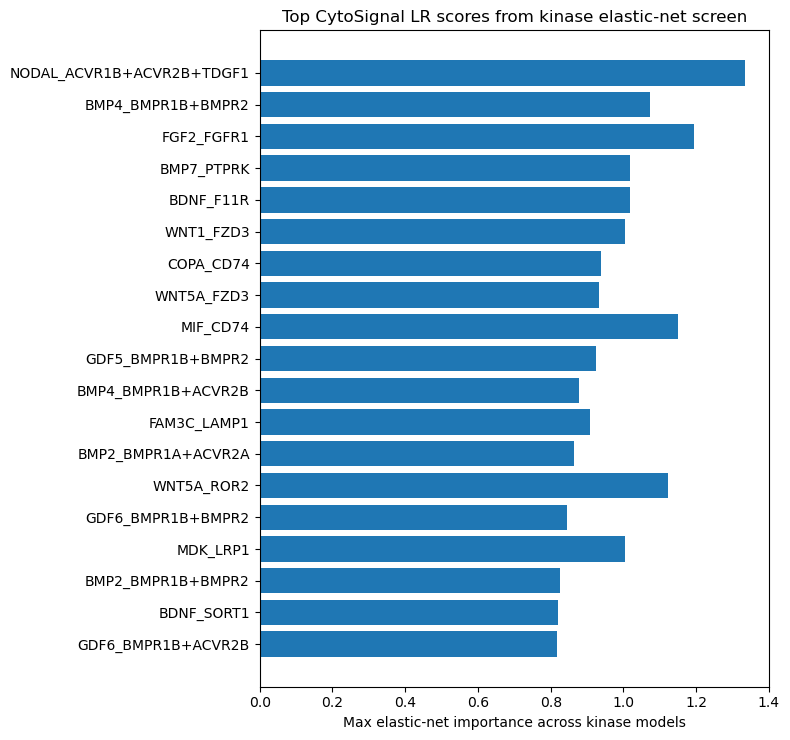

In [8]:
if lr_screen_long.empty:
    top_lr_scores_per_target_radius = pd.DataFrame()
    candidate_lr_scores = pd.DataFrame()
else:
    top_lr_scores_per_target_radius = (
        lr_screen_long.sort_values(['target', 'radius_um', 'elasticnet_importance'], ascending=[True, True, False])
        .groupby(['target', 'radius_um'], observed=True)
        .head(TOP_LR_PER_TARGET_RADIUS_FOR_OLS)
        .reset_index(drop=True)
    )
    candidate_lr_scores = top_lr_scores_per_target_radius.copy()
    global_importance = (
        lr_screen_long.groupby(['radius_um', 'lr_var_name'], as_index=False)
        .agg(
            mean_importance=('elasticnet_importance', 'mean'),
            max_importance=('elasticnet_importance', 'max'),
            n_target_models=('target', 'nunique'),
            ligand_name=('ligand_name', 'first'),
            receptor_name=('receptor_name', 'first'),
            lr_name=('lr_name', 'first'),
        )
        .sort_values(['max_importance', 'mean_importance'], ascending=False, ignore_index=True)
    )
    global_importance.to_csv(OUTPUT_DIR / 'lr_score_global_elasticnet_importance_summary.csv', index=False)

top_lr_scores_per_target_radius.to_csv(OUTPUT_DIR / 'top25_lr_scores_per_target_radius.csv', index=False)
candidate_lr_scores.to_csv(OUTPUT_DIR / 'candidate_lr_scores_for_single_lr_ols.csv', index=False)
print('Candidate rows for OLS:', len(candidate_lr_scores))
display(candidate_lr_scores.head(40))

if not lr_screen_long.empty:
    plot_df = global_importance.head(30).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(plot_df))))
    ax.barh(plot_df['lr_name'].fillna(plot_df['lr_var_name']).astype(str), plot_df['max_importance'])
    ax.set_xlabel('Max elastic-net importance across kinase models')
    ax.set_title('Top CytoSignal LR scores from kinase elastic-net screen')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'lr_elasticnet_screen_importance_qc.png', dpi=200)
    plt.show()